Dataset Shape: (15329, 10)

Head of Dataset:
   Order_ID  Order_Date   Region       City Customer_Type Product_Category  \
0    200000  2021-06-25     East  Ahmedabad           New         Clothing   
1    200001  2021-07-16     East    Kolkata     Returning             Food   
2    200002  2022-06-22  Central       Pune           New              NaN   
3    200003  2022-05-18    South       Pune           New        Furniture   
4    200004  2022-08-03  Central      Delhi     Returning      Accessories   

   Quantity  Unit_Price  Discount_Percent      Revenue  
0       1.0     1371.52               5.0    1302.9440  
1       6.0     3343.51               0.0   20061.0600  
2       4.0    24849.97              10.0   89459.8920  
3       7.0    30297.19              15.0  180268.2805  
4       8.0     8876.00              15.0   60356.8000  

Tail of Dataset:
       Order_ID  Order_Date   Region       City Customer_Type  \
15324    215324  2022-08-09    North    Chennai     Returning

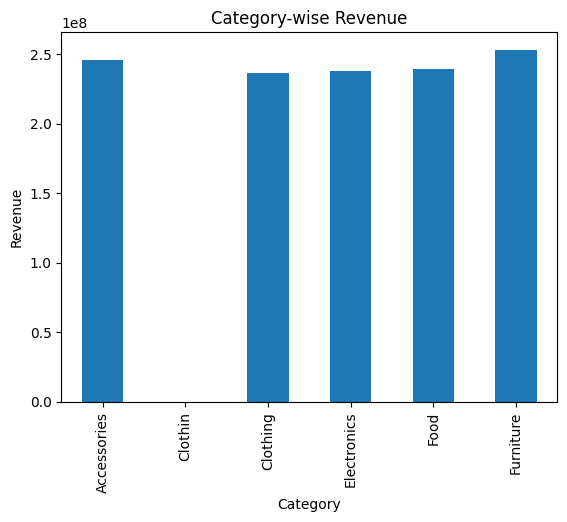

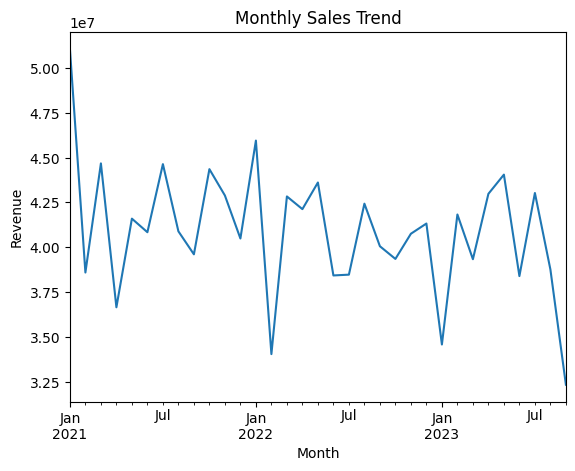

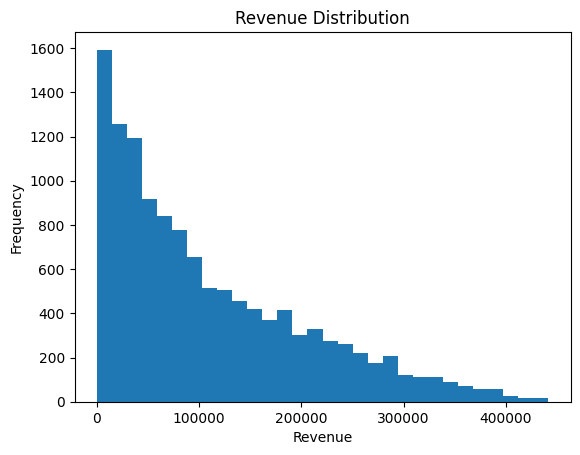

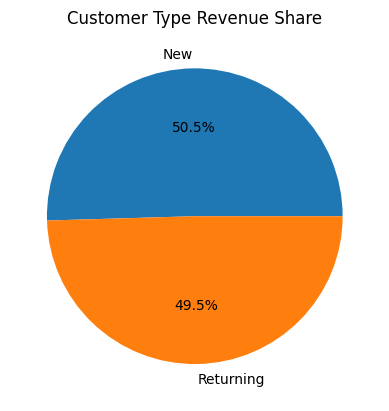

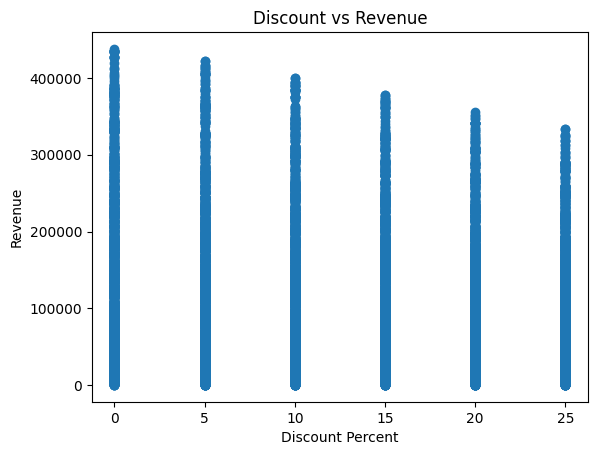

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Downloads/Indian_Retail_Business_Sales_Gigantic_Dataset_v2 - Indian_Retail_Business_Sales_Gigantic_Dataset_v2.csv.csv")

print("Dataset Shape:", df.shape)
print("\nHead of Dataset:")
print(df.head())

print("\nTail of Dataset:")
print(df.tail())
print("\nMissing Values:\n", df.isnull().sum())

df.drop_duplicates(inplace=True)

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

print("\nData Types:\n", df.dtypes)

print("\nDataset Description:")
print(df.describe())

print("\nProduct Category Counts:")
print(df["Product_Category"].value_counts())

region_revenue = df.groupby("Region")["Revenue"].sum()
category_revenue = df.groupby("Product_Category")["Revenue"].sum()
customer_revenue = df.groupby("Customer_Type")["Revenue"].sum()

df["Month"] = df["Order_Date"].dt.to_period("M")
monthly_sales = df.groupby("Month")["Revenue"].sum()

discount_revenue = df.groupby("Discount_Percent")["Revenue"].mean()

plt.figure()
category_revenue.plot(kind="bar")
plt.title("Category-wise Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.show()

plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

plt.figure()
plt.hist(df["Revenue"], bins=30)
plt.title("Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

plt.figure()
customer_revenue.plot(kind="pie", autopct="%1.1f%%")
plt.title("Customer Type Revenue Share")
plt.ylabel("")
plt.show()

plt.figure()
plt.scatter(df["Discount_Percent"], df["Revenue"])
plt.title("Discount vs Revenue")
plt.xlabel("Discount Percent")
plt.ylabel("Revenue")
plt.show()

